## phase1 : Loading and inspecting data

Load and Inspect Data: 

* Verify data structures and missing values.
* Load both CSV files into Pandas DataFrames.

In [2]:
import pandas as pd

movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

# recall : the head() function inPython pands returns the top 5 rows.
print(movies.head())
print(ratings.head())

print("Ratings info :")

# recall : the info() method returns a consice techincal summary of the Dataframe like : Class type(Confirms it is a Pandas Dataframe) , Index range (total number of rows) , Column count (total number of columns) ... etc
print(ratings.info())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
Ratings info :
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     ------

## Phase 2 : Merge the datasets

**Join movies and ratings on movieId so each row shows the movie title and its rating :**

In [15]:
df = pd.merge(ratings, movies, on='movieId')

print(df)

print(df.info())

        userId  movieId  rating   timestamp                           title  \
0            1        1     4.0   964982703                Toy Story (1995)   
1            1        3     4.0   964981247         Grumpier Old Men (1995)   
2            1        6     4.0   964982224                     Heat (1995)   
3            1       47     5.0   964983815     Seven (a.k.a. Se7en) (1995)   
4            1       50     5.0   964982931      Usual Suspects, The (1995)   
...        ...      ...     ...         ...                             ...   
100831     610   166534     4.0  1493848402                    Split (2017)   
100832     610   168248     5.0  1493850091   John Wick: Chapter Two (2017)   
100833     610   168250     5.0  1494273047                  Get Out (2017)   
100834     610   168252     5.0  1493846352                    Logan (2017)   
100835     610   170875     3.0  1493846415  The Fate of the Furious (2017)   

                                             genres

**Calculate average ratings (mean) and total rating counts (count) per movie:**

In [9]:
stats = df.groupby('title')['rating'].agg(['mean', 'count']).reset_index()

print(stats.head(10))

                                     title      mean  count
0                               '71 (2014)  4.000000      1
1  'Hellboy': The Seeds of Creation (2004)  4.000000      1
2                   'Round Midnight (1986)  3.500000      2
3                      'Salem's Lot (2004)  5.000000      1
4                'Til There Was You (1997)  4.000000      2
5          'Tis the Season for Love (2015)  1.500000      1
6                       'burbs, The (1989)  3.176471     17
7                     'night Mother (1986)  3.000000      1
8              (500) Days of Summer (2009)  3.666667     42
9           *batteries not included (1987)  3.285714      7


**Sort movies by Ratings average (mean) :**

In [10]:
# Filter out movies with very few ratings (e.g., less than 50 ratings)
popular_movies = stats[stats['count'] > 50].sort_values(by='mean', ascending=False)
print(popular_movies.head(10))

                                                  title      mean  count
7593                   Shawshank Redemption, The (1994)  4.429022    317
3499                              Godfather, The (1972)  4.289062    192
3011                                  Fight Club (1999)  4.272936    218
1961                              Cool Hand Luke (1967)  4.271930     57
2531  Dr. Strangelove or: How I Learned to Stop Worr...  4.268041     97
6999                                 Rear Window (1954)  4.261905     84
3500                     Godfather: Part II, The (1974)  4.259690    129
2334                               Departed, The (2006)  4.252336    107
3564                                  Goodfellas (1990)  4.250000    126
1593                                  Casablanca (1942)  4.240000    100


**Sort movies by Ratings count :**

In [12]:
# Filter out movies with very few ratings (e.g., less than 50 ratings)
popular_movies = stats[stats['count'] > 50].sort_values(by='count', ascending=False)
print(popular_movies.head(10))

                                          title      mean  count
3158                        Forrest Gump (1994)  4.164134    329
7593           Shawshank Redemption, The (1994)  4.429022    317
6865                        Pulp Fiction (1994)  4.197068    307
7680           Silence of the Lambs, The (1991)  4.161290    279
5512                         Matrix, The (1999)  4.192446    278
8001  Star Wars: Episode IV - A New Hope (1977)  4.231076    251
4662                       Jurassic Park (1993)  3.750000    238
1337                          Braveheart (1995)  4.031646    237
8363          Terminator 2: Judgment Day (1991)  3.970982    224
7421                    Schindler's List (1993)  4.225000    220


## TO BE CONTIUED

**Histogram of Rating counts and Rating Distributions :**

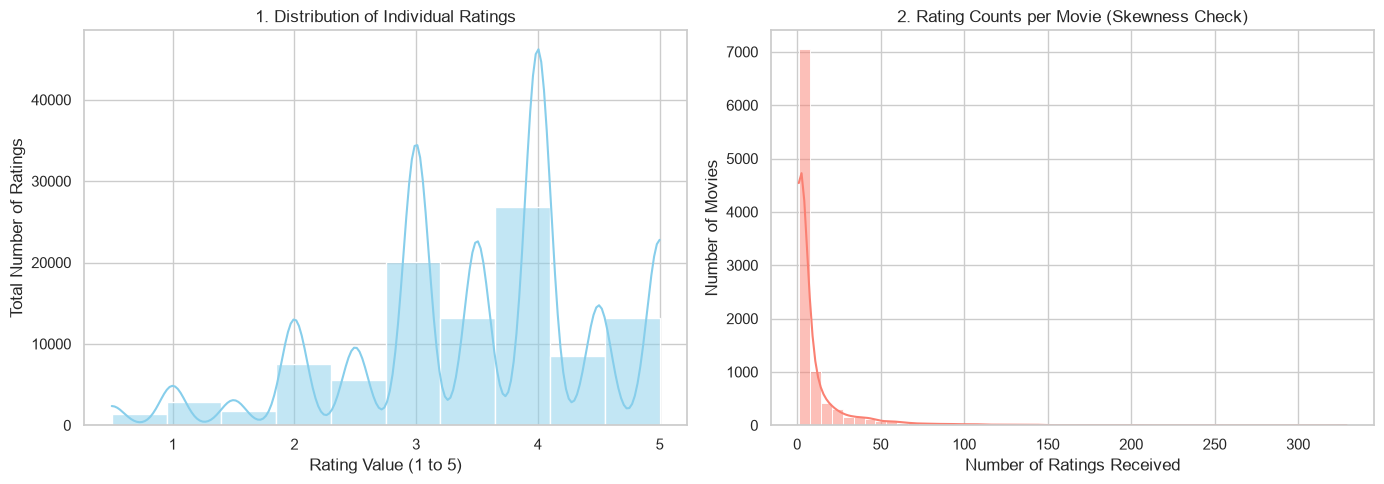

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# Plot 1: Distribution of Individual Ratings (1.0 to 5.0)
# ---------------------------------------------------------
sns.histplot(
    data=df, x="rating", bins=10, kde=True, ax=axes[0], color="skyblue"
)
axes[0].set_title("1. Distribution of Individual Ratings", fontsize=12)
axes[0].set_xlabel("Rating Value (1 to 5)")
axes[0].set_ylabel("Total Number of Ratings")

# ---------------------------------------------------------
# Plot 2: Distribution of Rating Counts per Movie
# ---------------------------------------------------------
movie_counts = df.groupby("title")["rating"].count()

sns.histplot(movie_counts, bins=50, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("2. Rating Counts per Movie (Skewness Check)", fontsize=12)
axes[1].set_xlabel("Number of Ratings Received")
axes[1].set_ylabel("Number of Movies")

plt.tight_layout()
plt.show()

## Phase 3 : Build the recommendation model :

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Fill missing genre data if any
movies['genres'] = movies['genres'].fillna('')

# 2. Vectorize genres using CountVectorizer
# token_pattern retains hyphens in genres like "Sci-Fi" or "Film-Noir"
cv = CountVectorizer(token_pattern=r'(?u)\b[\w-]+\b')
genre_matrix = cv.fit_transform(movies['genres'])

# 3. Compute Cosine Similarity Matrix
cosine_sim = cosine_similarity(genre_matrix, genre_matrix)

# 4. Function to get recommendations
def recommend_movies(title, top_n=5):
    # Get the row index of the given movie title
    idx = movies[movies['title'] == title].index[0]
    
    # Get pairwise similarity scores for all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort movies based on similarity score in descending order
    # [1:top_n+1] skips index 0 (because index 0 is the movie itself with score 1.0)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    # Extract the indices of the top matches
    movie_indices = [i[0] for i in sim_scores]
    
    # Return titles corresponding to those indices
    return movies['title'].iloc[movie_indices]

# Test it out
print(recommend_movies('Toy Story (1995)'))



1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: str


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Fill missing genre data if any
movies['genres'] = movies['genres'].fillna('')

# Vectorize genres
tfidf = TfidfVectorizer(token_pattern=r'(?u)\b[\w-]+\b')
genre_matrix = tfidf.fit_transform(movies['genres'])

# Compute Cosine Similarity Matrix
cosine_sim = cosine_similarity(genre_matrix, genre_matrix)

# Function to get recommendations
def recommend_movies(title, top_n=5):
    idx = movies[movies['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices]

# Test it out
print(recommend_movies('Toy Story (1995)'))

1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: str
